# 03 — Comparaison de modèles JEPA

On compare **deux checkpoints** sur exactement le même protocole d'éval, plus les
baselines model-free (popularité, répétition, kNN-contenu, identiques entre modèles).

| Clé | Checkpoint | Archi |
|---|---|---|
| **d128** | `jepa_baseline_d128.pt` | d_model=128, 2 couches temporelles (baseline, ep15) |
| **d256** | `jepa.pt` | d_model=256, 4 couches temporelles, ×3 params (scalé, ep21) |

Les deux **sans notes** (`use_ratings=False`) → cette comparaison isole l'effet du
**scale-up**. (Quand le run *avec notes* sera prêt, ajouter son checkpoint à `MODELS`.)

In [1]:
import sys
!{sys.executable} -m pip install -q umap-learn


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [2]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from src.data_prep import load_all, PROCESSED
from src.train_jepa import load_model
from src import evaluate_jepa as ev

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
EVAL_USERS = 8000

# clé -> (checkpoint, historique d'entraînement)  — ajouter ici le run avec notes plus tard
MODELS = {
    "d128 (baseline)": ("jepa_baseline_d128.pt", "train_history_baseline_d128.json"),
    "d256/4L (scalé)": ("jepa.pt", "train_history.json"),
}
COLORS = {"d128 (baseline)": "#4C78A8", "d256/4L (scalé)": "#F58518"}
print("device:", DEVICE, "| modèles:", list(MODELS))

device: mps | modèles: ['d128 (baseline)', 'd256/4L (scalé)']


## 1 — Santé de l'entraînement (courbes superposées)

`inv` = MSE centrée (à lire avec `pred_std`, non normalisée) ; `val_chunk_cos` doit
rester bas (~0.06) sinon effondrement.

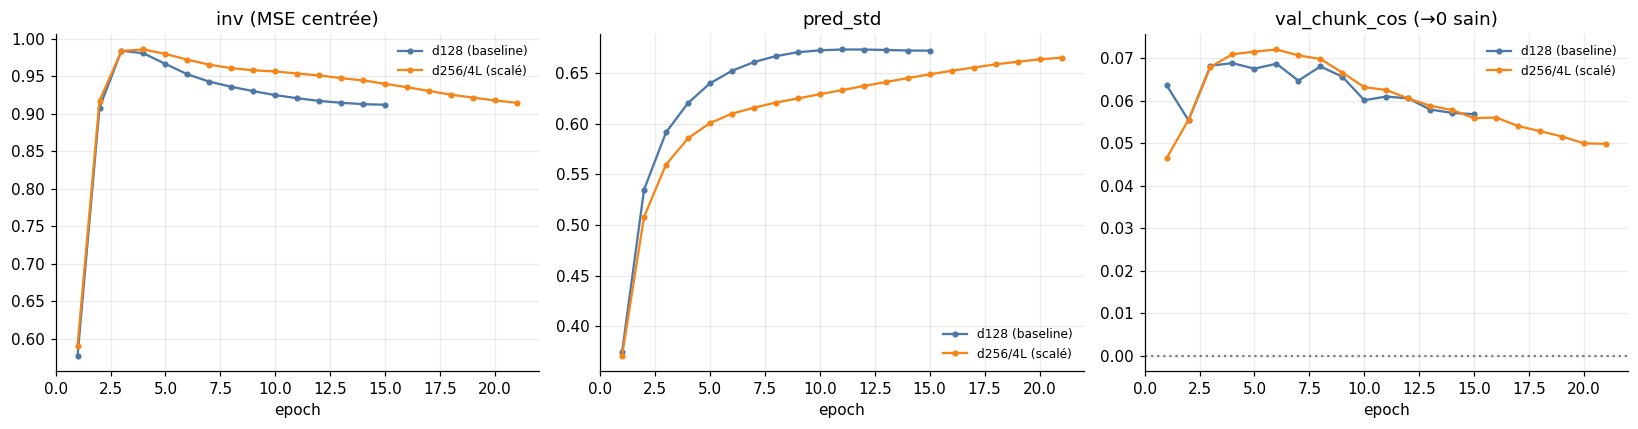

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for key, (_, hist_file) in MODELS.items():
    h = pd.DataFrame(json.load(open(PROCESSED / hist_file)))
    c = COLORS[key]
    axes[0].plot(h["epoch"], h["inv"], marker="o", ms=3, color=c, label=key)
    axes[1].plot(h["epoch"], h["pred_std"], marker="o", ms=3, color=c, label=key)
    axes[2].plot(h["epoch"], h["val_chunk_cos"], marker="o", ms=3, color=c, label=key)
axes[0].set(title="inv (MSE centrée)", xlabel="epoch")
axes[1].set(title="pred_std", xlabel="epoch")
axes[2].set(title="val_chunk_cos (→0 sain)", xlabel="epoch"); axes[2].axhline(0, color="grey", ls=":")
for a in axes: a.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 2 — Éval complète des deux modèles

`ev.evaluate_model` calcule toute la suite (diagnostics, retrieval films/chunks,
probes) par modèle. Quelques minutes par modèle.

In [4]:
sequences, genome, maps = load_all()
results = {}
for key, (ckpt, _) in MODELS.items():
    model = load_model(DEVICE, name=ckpt)
    results[key] = ev.evaluate_model(model, sequences, maps, genome, DEVICE, eval_users=EVAL_USERS)
    print(f"{key}: éval OK ({results[key]['n_eval']} users)")

# baseline kNN-contenu (model-free, identique entre modèles) — référence commune
eval_sub = sequences.sample(EVAL_USERS, random_state=0).reset_index(drop=True)
knn = ev.content_knn_retrieval(eval_sub, genome, maps, device=DEVICE)

d128 (baseline): éval OK (8000 users)


d256/4L (scalé): éval OK (8000 users)


## 3 — Retrieval films (vs popularité & kNN-contenu)

In [5]:
ks = (10, 20, 50, 100)
film = pd.DataFrame({key: results[key]["recall_film"] for key in MODELS}
                    | {"kNN-contenu": knn["recall_film"],
                       "Popularité": next(iter(results.values()))["recall_pop"]})
film.index.name = "Recall@K — films"
display((film * 100).round(2).astype(str) + " %")
print("Rang médian 1er bon film :",
      " | ".join(f"{k} {results[k]['median_rank_film']:.0f}" for k in MODELS),
      f"| kNN {knn['median_rank_film']:.0f}")

,d128 (baseline),d256/4L (scalé),kNN-contenu,Popularité
Recall@K — films,,,,
10,41.29 %,44.27 %,8.13 %,11.18 %
20,48.77 %,50.82 %,13.23 %,17.7 %
50,58.98 %,59.53 %,23.88 %,30.97 %
100,67.7 %,66.37 %,34.67 %,43.37 %


Rang médian 1er bon film : d128 (baseline) 22 | d256/4L (scalé) 18 | kNN 100


## 4 — Retrieval chunks (vs répétition & kNN-contenu)

In [6]:
chunk = pd.DataFrame({key: results[key]["recall_chunk"] for key in MODELS}
                     | {"kNN-contenu": knn["recall_chunk"],
                        "Répétition": next(iter(results.values()))["recall_repeat"]})
chunk.index.name = "Recall@K — chunks"
display((chunk * 100).round(2).astype(str) + " %")

,d128 (baseline),d256/4L (scalé),kNN-contenu,Répétition
Recall@K — chunks,,,,
1,3.0 %,3.63 %,0.36 %,0.08 %
5,9.78 %,10.6 %,1.76 %,0.33 %
10,14.98 %,15.48 %,2.96 %,0.76 %
20,21.3 %,22.19 %,4.71 %,1.7 %


## 5 — Diagnostics & probes de contenu

`rand_cos` bas = espace large (retrieval non trivial). Probes : R² genome / AUC genres
= le contexte encode-t-il le contenu futur ?

In [7]:
diag = pd.DataFrame({
    "cos aléatoire (espace)": {k: results[k]["rand_cos"] for k in MODELS},
    "anisotropie": {k: results[k]["anisotropy"] for k in MODELS},
    "probe genome R²": {k: results[k]["probe_genome_r2"] for k in MODELS},
    "probe genres AUC": {k: results[k]["probe_genres_auc"] for k in MODELS},
}).T.round(3)
display(diag)

,d128 (baseline),d256/4L (scalé)
cos aléatoire (espace),0.060,0.050
anisotropie,0.245,0.226
probe genome R²,0.258,0.219
probe genres AUC,0.684,0.668


## 6 — UMAP des chunks (côte à côte)

Projection non-linéaire colorée par genre dominant. On regarde si la séparation par
genre est plus nette pour un modèle. (PCA en dessous = contrôle linéaire.)

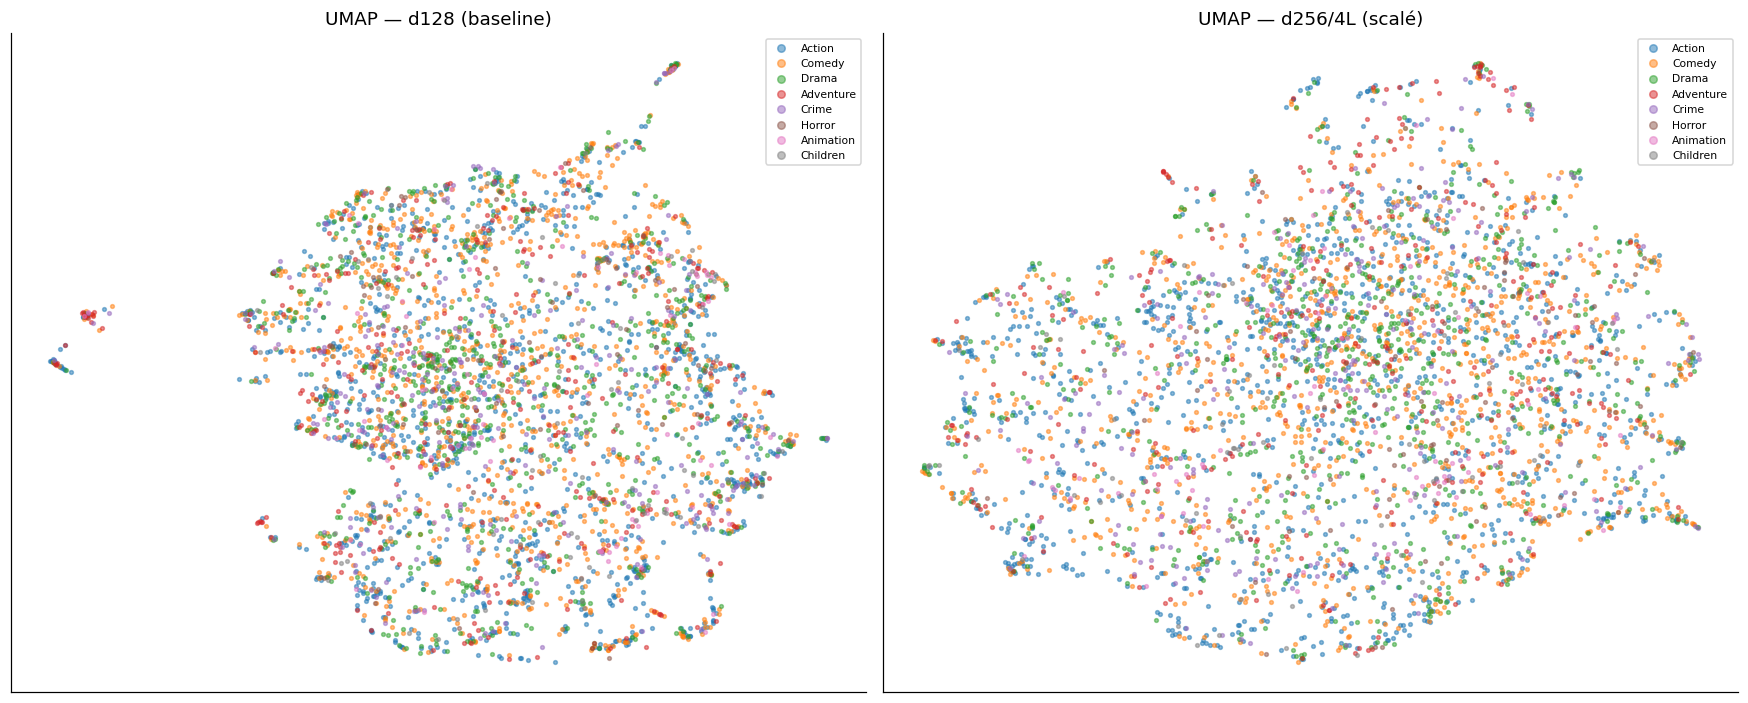

d128 (baseline): variance PCA expliquée 3D = 3.5% (PC1 1.2 / PC2 1.1 / PC3 1.1)


d256/4L (scalé): variance PCA expliquée 3D = 1.9% (PC1 0.6 / PC2 0.6 / PC3 0.6)


In [8]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(8 * len(MODELS), 6.5))
axes = np.atleast_1d(axes)
for ax, (key, (ckpt, _)) in zip(axes, MODELS.items()):
    model = load_model(DEVICE, name=ckpt)
    proj, gen = ev.umap_chunks(model, sequences, maps, DEVICE, n_chunks=4000)
    gen = np.array(gen); top = pd.Series(gen).value_counts().head(8).index.tolist()
    for g in top:
        m = gen == g
        ax.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.5, label=g)
    ax.set_title(f"UMAP — {key}"); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=7, loc="best")
plt.tight_layout(); plt.show()

# contrôle PCA : variance expliquée 2D (bas = espace isotrope, structure non-linéaire)
for key, (ckpt, _) in MODELS.items():
    model = load_model(DEVICE, name=ckpt)
    _, _, evr = ev.pca_chunks(model, sequences, maps, DEVICE, n_chunks=4000, n_components=3)
    print(f"{key}: variance PCA expliquée 3D = {evr[:3].sum()*100:.1f}% "
          f"(PC1 {evr[0]*100:.1f} / PC2 {evr[1]*100:.1f} / PC3 {evr[2]*100:.1f})")

## Verdict

Grille de lecture de la comparaison **d128 → d256/4L** (scale-up, ×3 params, sans notes) :

- **Courbes** : `inv` du scalé bat-il le baseline, ou colle-t-il (→ capacité pas le levier) ?
- **Retrieval films/chunks** : le vrai juge. Gain net = le scale-up sert. ≈ égal = plafond
  côté données/signal (cf. notebook 04, signal court-portée).
- **Probes/diagnostics** : l'espace reste-t-il large (`rand_cos` bas) et informatif ?

Rappel baselines : popularité & répétition sont des planchers ; **kNN-contenu** est le
juge sérieux. Prochaine étape : ajouter le run **avec notes** à `MODELS` pour mesurer
l'apport de la feature note, à archi égale.